
# Análise de Desempenho de Sistemas de Filas com Diferentes Estratégias

Este notebook tem como objetivo realizar a simulação e análise de desempenho de quatro modelos de filas:

-  **Duas Filas Paralelas (Escolha da Menor Fila)**
-  **Fila Única (M/G/2)**
-  **Sem Fila (M/G/2/0 - sistema com perda)**
-  **Fila Única com Capacidade Limitada (M/G/2/K)**

### Modelo 1 - Duas Filas Paralelas (Escolha da Menor Fila)
- Chegadas Poisson (λ).
- Clientes escolhem a menor fila, ou aleatoriamente em caso de empate.
- Cada fila tem seu próprio servidor.
- Tempos de serviço seguem uma distribuição genérica (Exponencial, Normal ou Uniforme).

### Modelo 2 - Fila Única (M/G/2)
- Uma única fila atendida por dois servidores.
- O cliente vai para o primeiro servidor livre.
- Tempos de serviço seguem uma distribuição genérica.

### Modelo 3 - Sem Fila (M/G/2/0)
- Sistema com perda: se ambos os servidores estão ocupados, o cliente é perdido.
- Não há fila de espera.
- Modelo útil para simular sistemas onde não há capacidade de espera.

### Modelo 4 - Fila Única com Capacidade Limitada (M/G/2/K)
- Uma única fila para dois servidores, porém com limite na capacidade da fila.
- Exemplo: 2 servidores + 5 na fila → capacidade total = 7.
- Se o limite for atingido, os clientes que chegam são perdidos.
- Permite analisar o impacto de restrições físicas ou operacionais.
---
Serão analisadas diferentes distribuições para o tempo de serviço:
- Exponencial
- Normal truncada
- Uniforme

E diferentes tamanhos de fila, incluindo:
- Fila infinita
- Sem fila (perda)
- Fila com capacidade limitada

As métricas avaliadas incluem:
- Tempo médio no sistema
- Tempo médio na fila
- Utilização média dos servidores
- Probabilidade de perda (quando aplicável)




## Definição dos Modelos de Filas




In [100]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns
import scipy.stats as st
from matplotlib import gridspec

# Configurações globais de visualização
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [101]:
"""
Parâmetros globais da simulação.
"""

# Taxas de chegada (lambda) — variaremos de 1 até 3 para análises
arrival_rates = [1, 1.5, 2, 2.5, 3]

# Taxa de serviço (mu)
service_rate = 1.5  # Média = 1/μ

# Tempo total de simulação
SIM_TIME = 10000  # unidades de tempo

# Tamanhos das filas
QUEUE_LIMIT = {
    'infinite': None,  # fila infinita
    'limited': 5,      # máximo 5 clientes na fila
    'no_queue': 0      # sem fila (sistema com perda)
}

# Distribuições de serviço disponíveis
SERVICE_DISTRIBUTIONS = ['exponential', 'normal', 'uniform']

## Função de Geração de Tempo de Serviço

In [102]:
"""
Função para geração dos tempos de serviço conforme a distribuição escolhida.
"""


def generate_service_time(distribution: str, mu: float) -> float:
    """
    Gera um tempo de serviço baseado na distribuição escolhida.

    Args:
        distribution (str): Tipo da distribuição. Opções:
            - 'exponential'
            - 'normal'
            - 'uniform'
        mu (float): Taxa de serviço (média = 1/mu).

    Returns:
        float: Tempo de serviço gerado.
    """
    if distribution == 'exponential':
        return np.random.exponential(1 / mu)

    elif distribution == 'normal':
        mean = 1 / mu
        std_dev = mean * 0.2  # 20% de desvio padrão
        value = np.random.normal(loc=mean, scale=std_dev)
        return max(value, 0.0001)  # Truncar valores negativos

    elif distribution == 'uniform':
        mean = 1 / mu
        low = mean * 0.5
        high = mean * 1.5
        return np.random.uniform(low, high)

    else:
        raise ValueError(
            "Distribuição inválida. Escolha entre: 'exponential', 'normal', 'uniform'."
        )


## Função de Geração de Chegadas

In [103]:
"""
Função para geração do intervalo entre chegadas (processo de Poisson).
"""


def generate_interarrival_time(lam: float) -> float:
    """
    Gera o tempo até a próxima chegada com base em um processo de Poisson.

    Args:
        lam (float): Taxa de chegada (λ).

    Returns:
        float: Tempo até a próxima chegada.
    """
    return np.random.exponential(1 / lam)


## Implementação do Modelo 1 - Duas Filas Paralelas (Escolha da Menor Fila)

In [104]:
"""
Simulação do modelo de duas filas paralelas com escolha da menor fila.
"""

def simulate_two_parallel_queues(lam: float, mu: float, distribution: str, sim_time: int) -> dict:
    """
    Simula um sistema com duas filas paralelas, onde os clientes escolhem a menor fila.

    Args:
        lam (float): Taxa de chegada (λ).
        mu (float): Taxa de serviço (μ).
        distribution (str): Distribuição do tempo de serviço ('exponential', 'normal', 'uniform').
        sim_time (int): Tempo total de simulação.

    Returns:
        dict: Métricas da simulação:
            - avg_waiting_time: Tempo médio na fila.
            - avg_system_time: Tempo médio no sistema (fila + serviço).
            - utilization_server_1: Utilização do servidor 1.
            - utilization_server_2: Utilização do servidor 2.
            - avg_queue_length_1: Tamanho médio da fila 1.
            - avg_queue_length_2: Tamanho médio da fila 2.
    """

    # Inicialização do ambiente
    env = simpy.Environment()

    # Definição dos servidores
    server_1 = simpy.Resource(env, capacity=1)
    server_2 = simpy.Resource(env, capacity=1)

    # Dados para coleta
    waiting_times = []
    system_times = []
    queue_lengths_1 = []
    queue_lengths_2 = []
    busy_time_server_1 = 0
    busy_time_server_2 = 0

    # Controle dos tempos ocupados dos servidores
    server_1_busy_start = []
    server_2_busy_start = []

    def customer(name: str, env: simpy.Environment):
        """
        Processo de um cliente no sistema.
        """
        nonlocal busy_time_server_1, busy_time_server_2

        arrival_time = env.now

        # Verifica tamanhos das filas
        q_len_1 = len(server_1.queue)
        q_len_2 = len(server_2.queue)

        # Escolhe a menor fila, empate por Bernoulli
        if q_len_1 < q_len_2:
            chosen_server = server_1
        elif q_len_2 < q_len_1:
            chosen_server = server_2
        else:
            chosen_server = np.random.choice([server_1, server_2])

        with chosen_server.request() as request:
            queue_entry_time = env.now
            yield request
            queue_exit_time = env.now

            waiting_time = queue_exit_time - queue_entry_time
            service_time = generate_service_time(distribution, mu)

            # Início do serviço (ocupação do servidor)
            if chosen_server == server_1:
                server_1_busy_start.append(env.now)
            else:
                server_2_busy_start.append(env.now)

            yield env.timeout(service_time)

            # Fim do serviço (registro tempo ocupado)
            if chosen_server == server_1:
                busy_time_server_1 += service_time
            else:
                busy_time_server_2 += service_time

            departure_time = env.now

            waiting_times.append(waiting_time)
            system_times.append(departure_time - arrival_time)

    def arrival_process(env: simpy.Environment):
        """
        Processo de chegada dos clientes.
        """
        customer_count = 0
        while True:
            interarrival = generate_interarrival_time(lam)
            yield env.timeout(interarrival)
            customer_count += 1
            env.process(customer(f'Cliente {customer_count}', env))

            # Registrar tamanho das filas periodicamente
            queue_lengths_1.append(len(server_1.queue))
            queue_lengths_2.append(len(server_2.queue))

    # Inicia o processo de chegada
    env.process(arrival_process(env))

    # Executa a simulação
    env.run(until=sim_time)

    # Calcula métricas
    avg_waiting_time = np.mean(waiting_times) if waiting_times else 0
    avg_system_time = np.mean(system_times) if system_times else 0
    utilization_server_1 = busy_time_server_1 / sim_time
    utilization_server_2 = busy_time_server_2 / sim_time
    avg_queue_length_1 = np.mean(queue_lengths_1) if queue_lengths_1 else 0
    avg_queue_length_2 = np.mean(queue_lengths_2) if queue_lengths_2 else 0

    return {
        'avg_waiting_time': avg_waiting_time,
        'avg_system_time': avg_system_time,
        'utilization_server_1': utilization_server_1,
        'utilization_server_2': utilization_server_2,
        'avg_queue_length_1': avg_queue_length_1,
        'avg_queue_length_2': avg_queue_length_2
    }


## Implementação do Modelo 2 - Fila Única (M/G/2)

In [105]:
"""
Simulação do modelo de fila única com dois servidores (M/G/2).
"""


def simulate_single_queue(lam: float, mu: float, distribution: str, sim_time: int) -> dict:
    """
    Simula um sistema de fila única com dois servidores.

    Args:
        lam (float): Taxa de chegada (λ).
        mu (float): Taxa de serviço (μ).
        distribution (str): Distribuição do tempo de serviço ('exponential', 'normal', 'uniform').
        sim_time (int): Tempo total de simulação.

    Returns:
        dict: Métricas da simulação:
            - avg_waiting_time: Tempo médio na fila.
            - avg_system_time: Tempo médio no sistema (fila + serviço).
            - utilization_server_1: Utilização do servidor 1.
            - utilization_server_2: Utilização do servidor 2.
            - avg_queue_length: Tamanho médio da fila.
    """

    env = simpy.Environment()

    server = simpy.Resource(env, capacity=2)

    waiting_times = []
    system_times = []
    queue_lengths = []
    busy_time_server_1 = 0
    busy_time_server_2 = 0

    def customer(name: str, env: simpy.Environment):
        nonlocal busy_time_server_1, busy_time_server_2

        arrival_time = env.now

        with server.request() as request:
            queue_entry_time = env.now
            yield request
            queue_exit_time = env.now

            waiting_time = queue_exit_time - queue_entry_time
            service_time = generate_service_time(distribution, mu)

            if busy_time_server_1 <= busy_time_server_2:
                busy_time_server_1 += service_time
            else:
                busy_time_server_2 += service_time

            yield env.timeout(service_time)

            departure_time = env.now

            waiting_times.append(waiting_time)
            system_times.append(departure_time - arrival_time)

    def arrival_process(env: simpy.Environment):
        customer_count = 0
        while True:
            interarrival = generate_interarrival_time(lam)
            yield env.timeout(interarrival)
            customer_count += 1
            env.process(customer(f'Cliente {customer_count}', env))
            queue_lengths.append(len(server.queue))

    env.process(arrival_process(env))
    env.run(until=sim_time)

    avg_waiting_time = np.mean(waiting_times) if waiting_times else 0
    avg_system_time = np.mean(system_times) if system_times else 0
    utilization_server_1 = busy_time_server_1 / sim_time
    utilization_server_2 = busy_time_server_2 / sim_time
    avg_queue_length = np.mean(queue_lengths) if queue_lengths else 0

    return {
        'avg_waiting_time': avg_waiting_time,
        'avg_system_time': avg_system_time,
        'utilization_server_1': utilization_server_1,
        'utilization_server_2': utilization_server_2,
        'avg_queue_length': avg_queue_length
    }


## Implementação do Modelo 3 - Sistema Sem Fila (M/G/2/0)

In [106]:
"""
Simulação do modelo sem fila (M/G/2/0) — sistema com perda.
"""


def simulate_no_queue_system(lam: float, mu: float, distribution: str, sim_time: int) -> dict:
    """
    Simula um sistema com dois servidores e sem fila (M/G/2/0).

    Args:
        lam (float): Taxa de chegada (λ).
        mu (float): Taxa de serviço (μ).
        distribution (str): Distribuição do tempo de serviço ('exponential', 'normal', 'uniform').
        sim_time (int): Tempo total de simulação.

    Returns:
        dict: Métricas da simulação:
            - avg_system_time: Tempo médio no sistema (apenas serviço, não há fila).
            - utilization_server_1: Utilização do servidor 1.
            - utilization_server_2: Utilização do servidor 2.
            - loss_probability: Probabilidade de perda (cliente chega e não é atendido).
            - total_customers: Total de clientes que chegaram.
            - lost_customers: Total de clientes perdidos.
    """

    # Inicialização do ambiente
    env = simpy.Environment()

    # Definição dos servidores (sem fila, apenas capacidade 2)
    server = simpy.Resource(env, capacity=2)

    # Dados para coleta
    system_times = []
    busy_time_server_1 = 0
    busy_time_server_2 = 0
    total_customers = 0
    lost_customers = 0

    def customer(name: str, env: simpy.Environment):
        """
        Processo de um cliente no sistema.
        """
        nonlocal busy_time_server_1, busy_time_server_2
        nonlocal total_customers, lost_customers

        arrival_time = env.now
        total_customers += 1

        if len(server.queue) == 0 and server.count < 2:
            with server.request() as request:
                yield request

                service_time = generate_service_time(distribution, mu)

                if busy_time_server_1 <= busy_time_server_2:
                    busy_time_server_1 += service_time
                else:
                    busy_time_server_2 += service_time

                yield env.timeout(service_time)

                departure_time = env.now
                system_times.append(departure_time - arrival_time)

        else:
            # Cliente perdido por falta de capacidade
            lost_customers += 1

    def arrival_process(env: simpy.Environment):
        """
        Processo de chegada dos clientes.
        """
        customer_count = 0
        while True:
            interarrival = generate_interarrival_time(lam)
            yield env.timeout(interarrival)
            customer_count += 1
            env.process(customer(f'Cliente {customer_count}', env))

    # Inicia o processo de chegada
    env.process(arrival_process(env))

    # Executa a simulação
    env.run(until=sim_time)

    # Calcula métricas
    avg_system_time = np.mean(system_times) if system_times else 0
    utilization_server_1 = busy_time_server_1 / sim_time
    utilization_server_2 = busy_time_server_2 / sim_time
    loss_probability = lost_customers / total_customers if total_customers else 0

    return {
        'avg_system_time': avg_system_time,
        'utilization_server_1': utilization_server_1,
        'utilization_server_2': utilization_server_2,
        'loss_probability': loss_probability,
        'total_customers': total_customers,
        'lost_customers': lost_customers
    }


## Modelo 4 - Fila Única Limitada

In [107]:

def simulate_limited_queue(
    lam: float, mu: float, distribution: str,
    sim_time: int, n_servers: int = 2, queue_limit: int = 5
) -> dict:
    """
    Simula um sistema de fila única com capacidade limitada.

    Args:
        lam (float): Taxa de chegada (λ).
        mu (float): Taxa de serviço (μ).
        distribution (str): Distribuição do tempo de serviço ('exponential', 'normal', 'uniform').
        sim_time (int): Tempo total de simulação.
        n_servers (int): Número de servidores (default = 2).
        queue_limit (int): Capacidade da fila (default = 5).

    Returns:
        dict: Métricas da simulação.
    """
    env = simpy.Environment()

    total_capacity = n_servers + queue_limit
    server = simpy.Resource(env, capacity=total_capacity)

    waiting_times = []
    system_times = []
    queue_lengths = []
    busy_times = [0] * n_servers

    total_customers = 0
    lost_customers = 0

    def customer(name: str, env: simpy.Environment):
        nonlocal busy_times, total_customers, lost_customers

        arrival_time = env.now
        total_customers += 1

        if server.count < total_capacity:
            with server.request() as request:
                queue_entry_time = env.now
                yield request
                queue_exit_time = env.now

                waiting_time = queue_exit_time - queue_entry_time
                service_time = generate_service_time(distribution, mu)

                idx = np.argmin(busy_times)
                busy_times[idx] += service_time

                yield env.timeout(service_time)

                departure_time = env.now

                waiting_times.append(waiting_time)
                system_times.append(departure_time - arrival_time)
        else:
            lost_customers += 1

    def arrival_process(env: simpy.Environment):
        customer_count = 0
        while True:
            interarrival = generate_interarrival_time(lam)
            yield env.timeout(interarrival)
            customer_count += 1
            env.process(customer(f'Cliente {customer_count}', env))
            queue_lengths.append(max(len(server.queue) - n_servers, 0))

    env.process(arrival_process(env))
    env.run(until=sim_time)

    avg_waiting_time = np.mean(waiting_times) if waiting_times else 0
    avg_system_time = np.mean(system_times) if system_times else 0
    avg_queue_length = np.mean(queue_lengths) if queue_lengths else 0
    utilization = [bt / sim_time for bt in busy_times]
    avg_utilization = np.mean(utilization)
    loss_probability = lost_customers / total_customers if total_customers else 0

    return {
        'avg_waiting_time': avg_waiting_time,
        'avg_system_time': avg_system_time,
        'avg_queue_length': avg_queue_length,
        'avg_utilization': avg_utilization,
        'loss_probability': loss_probability,
        'total_customers': total_customers,
        'lost_customers': lost_customers,
        'n_servers': n_servers,
        'queue_limit': queue_limit
    }


## Execução das Simulações

In [108]:
"""
Execução das simulações para os quatro modelos de filas.
"""

# Lista para armazenar os resultados
results = []

# Loop para cada distribuição de serviço
for distribution in SERVICE_DISTRIBUTIONS:
    print(f"\nIniciando simulações para distribuição: {distribution}")

    # Loop para cada taxa de chegada (lambda)
    for lam in arrival_rates:
        print(f"  -> Taxa de chegada (lambda) = {lam}")

        # 🔹 Modelo 1 — Duas filas paralelas
        res_parallel = simulate_two_parallel_queues(
            lam=lam, mu=service_rate,
            distribution=distribution, sim_time=SIM_TIME
        )
        res_parallel.update({
            'lambda': lam,
            'distribution': distribution,
            'model': 'Two Parallel Queues'
        })
        results.append(res_parallel)

        # 🔹 Modelo 2 — Fila única (M/G/2)
        res_single = simulate_single_queue(
            lam=lam, mu=service_rate,
            distribution=distribution, sim_time=SIM_TIME
        )
        res_single.update({
            'lambda': lam,
            'distribution': distribution,
            'model': 'Single Queue'
        })
        results.append(res_single)

        # 🔹 Modelo 3 — Sem fila (M/G/2/0 — sistema com perda)
        res_noqueue = simulate_no_queue_system(
            lam=lam, mu=service_rate,
            distribution=distribution, sim_time=SIM_TIME
        )
        res_noqueue.update({
            'lambda': lam,
            'distribution': distribution,
            'model': 'No Queue'
        })
        results.append(res_noqueue)

        # 🔹 Modelo 4 — Fila única com capacidade limitada (M/G/2/5)
        res_limited = simulate_limited_queue(
            lam=lam, mu=service_rate,
            distribution=distribution, sim_time=SIM_TIME,
            n_servers=2, queue_limit=5  # Definindo a capacidade limitada
        )
        res_limited.update({
            'lambda': lam,
            'distribution': distribution,
            'model': 'Limited Queue'
        })
        results.append(res_limited)

print("\n✅ Simulações concluídas!")



Iniciando simulações para distribuição: exponential
  -> Taxa de chegada (lambda) = 1
  -> Taxa de chegada (lambda) = 1.5
  -> Taxa de chegada (lambda) = 2
  -> Taxa de chegada (lambda) = 2.5
  -> Taxa de chegada (lambda) = 3

Iniciando simulações para distribuição: normal
  -> Taxa de chegada (lambda) = 1
  -> Taxa de chegada (lambda) = 1.5
  -> Taxa de chegada (lambda) = 2
  -> Taxa de chegada (lambda) = 2.5
  -> Taxa de chegada (lambda) = 3

Iniciando simulações para distribuição: uniform
  -> Taxa de chegada (lambda) = 1
  -> Taxa de chegada (lambda) = 1.5
  -> Taxa de chegada (lambda) = 2
  -> Taxa de chegada (lambda) = 2.5
  -> Taxa de chegada (lambda) = 3

✅ Simulações concluídas!


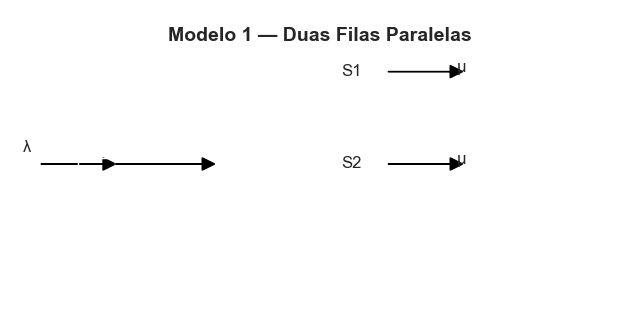

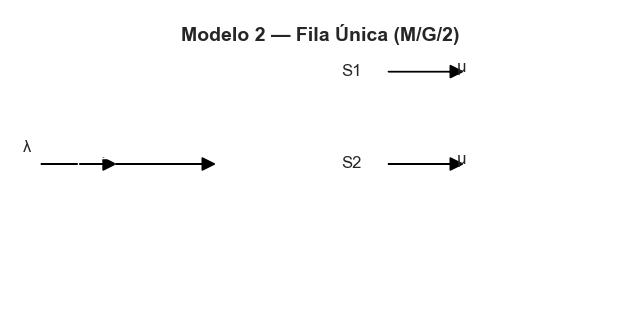

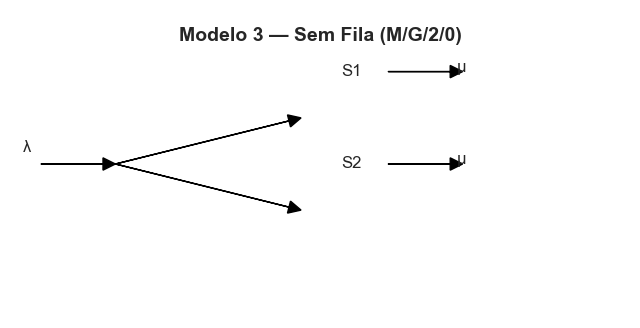

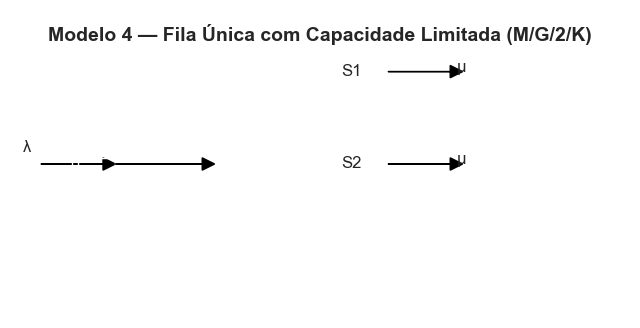

In [109]:
def draw_queue_diagram(title, with_queue=True, servers=2, queue_limit=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis('off')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 5)

    # Title
    ax.text(5, 4.5, title, fontsize=14, ha='center', weight='bold')

    # Arrival arrow
    ax.arrow(0.5, 2.5, 1.0, 0, head_width=0.2, head_length=0.2, fc='black', ec='black')
    ax.text(0.2, 2.7, 'λ', fontsize=12)

    # Servers
    for i in range(servers):
        ax.add_patch(patches.Rectangle((5, 3.5 - i * 1.5), 1, 1, fill=False))
        ax.text(5.5, 4 - i * 1.5, f'S{i + 1}', ha='center', va='center')

        # Departure arrow
        ax.arrow(6.1, 4 - i * 1.5, 1.0, 0, head_width=0.2, head_length=0.2, fc='black', ec='black')
        ax.text(7.2, 4 - i * 1.5, 'μ', fontsize=12)

    # Queue
    if with_queue:
        queue_len = queue_limit if queue_limit is not None else 4
        for i in range(queue_len):
            ax.add_patch(patches.Rectangle((3.2 - i * 0.7, 2), 0.6, 0.6, fill=False))

        ax.arrow(1.7, 2.5, 1.4, 0, head_width=0.2, head_length=0.2, fc='black', ec='black')

    else:
        # No queue, arrival directly to server
        ax.arrow(1.7, 2.5, 2.8, 0.7, head_width=0.2, head_length=0.2, fc='black', ec='black')
        ax.arrow(1.7, 2.5, 2.8, -0.7, head_width=0.2, head_length=0.2, fc='black', ec='black')

    plt.show()


# Desenhar os quatro modelos
draw_queue_diagram('Modelo 1 — Duas Filas Paralelas', with_queue=True, servers=2, queue_limit=None)
draw_queue_diagram('Modelo 2 — Fila Única (M/G/2)', with_queue=True, servers=2, queue_limit=None)
draw_queue_diagram('Modelo 3 — Sem Fila (M/G/2/0)', with_queue=False, servers=2, queue_limit=0)
draw_queue_diagram('Modelo 4 — Fila Única com Capacidade Limitada (M/G/2/K)', with_queue=True, servers=2, queue_limit=5)


In [110]:
"""
Organização dos resultados em um DataFrame.
"""

# Cria o DataFrame
df_results = pd.DataFrame(results)

# Exibe os primeiros resultados
df_results.head()

,avg_waiting_time,avg_system_time,utilization_server_1,utilization_server_2,avg_queue_length_1,avg_queue_length_2,lambda,distribution,model,avg_queue_length,loss_probability,total_customers,lost_customers,avg_utilization,n_servers,queue_limit
0,0.201879,0.861195,0.328411,0.324773,0.105157,0.096074,1.0,exponential,Two Parallel Queues,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.077696,0.744428,0.332996,0.332972,NaN,NaN,1.0,exponential,Single Queue,0.065973,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,0.664784,0.297586,0.297550,NaN,NaN,1.0,exponential,No Queue,NaN,0.121934,10194.0,1243.0,NaN,NaN,NaN
3,0.000000,0.671446,NaN,NaN,NaN,NaN,1.0,exponential,Limited Queue,0.000000,0.000000,10065.0,0.0,0.337912,2.0,5.0
4,0.374037,1.042987,0.503730,0.501702,0.289876,0.283225,1.5,exponential,Two Parallel Queues,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Gráfico: Tempo Médio no Sistema

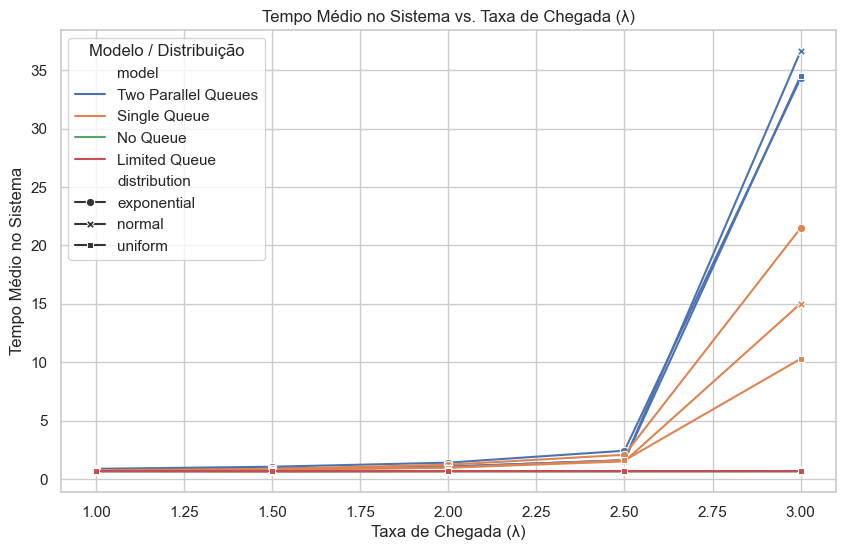

In [111]:
"""
Gráfico: Tempo médio no sistema vs. Taxa de chegada (lambda).
"""

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_results,
    x="lambda", y="avg_system_time",
    hue="model", style="distribution", markers=True, dashes=False
)
plt.title("Tempo Médio no Sistema vs. Taxa de Chegada (λ)")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Tempo Médio no Sistema")
plt.legend(title="Modelo / Distribuição")
plt.grid(True)
plt.show()


## Gráfico: Tempo Médio na Fila (Quando Aplicável)

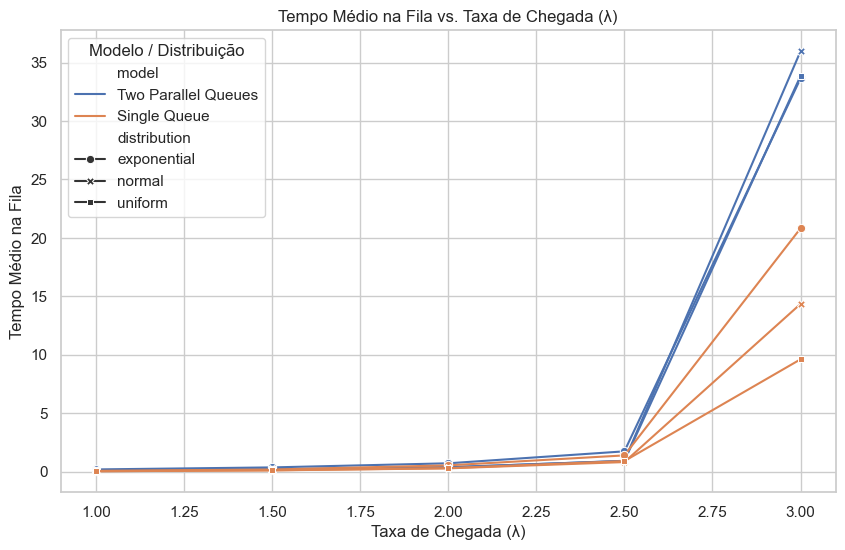

In [112]:
"""
Gráfico: Tempo médio na fila vs. Taxa de chegada (lambda).
"""

# Filtrar modelos que possuem fila
df_queue = df_results[df_results['model'].isin(['Two Parallel Queues', 'Single Queue'])]

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_queue,
    x="lambda", y="avg_waiting_time",
    hue="model", style="distribution", markers=True, dashes=False
)
plt.title("Tempo Médio na Fila vs. Taxa de Chegada (λ)")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Tempo Médio na Fila")
plt.legend(title="Modelo / Distribuição")
plt.grid(True)
plt.show()


## Gráfico: Utilização dos Servidores

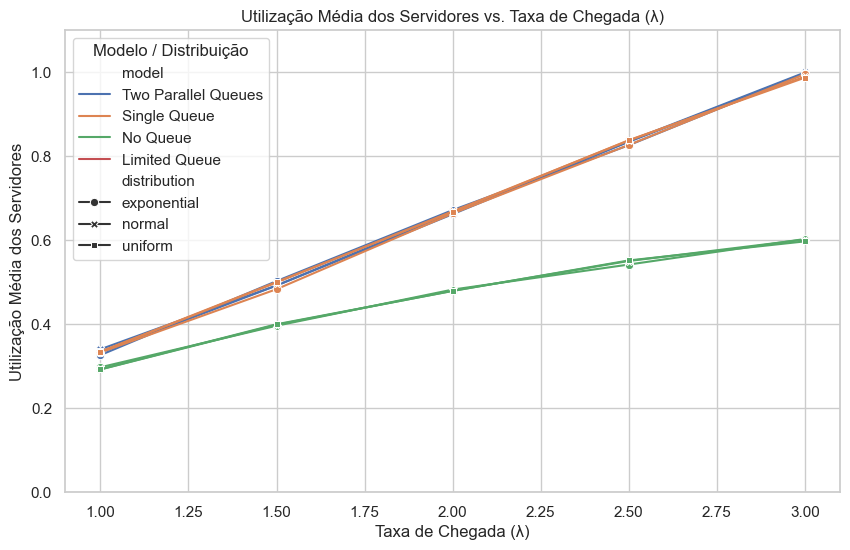

In [113]:
"""
Gráfico: Utilização média dos servidores vs. Taxa de chegada (lambda).
"""

# Média da utilização dos dois servidores
df_results['avg_utilization'] = (df_results['utilization_server_1'] + df_results['utilization_server_2']) / 2

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_results,
    x="lambda", y="avg_utilization",
    hue="model", style="distribution", markers=True, dashes=False
)
plt.title("Utilização Média dos Servidores vs. Taxa de Chegada (λ)")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Utilização Média dos Servidores")
plt.ylim(0, 1.1)
plt.legend(title="Modelo / Distribuição")
plt.grid(True)
plt.show()


## Gráfico: Probabilidade de Perda (Somente Modelo Sem Fila)

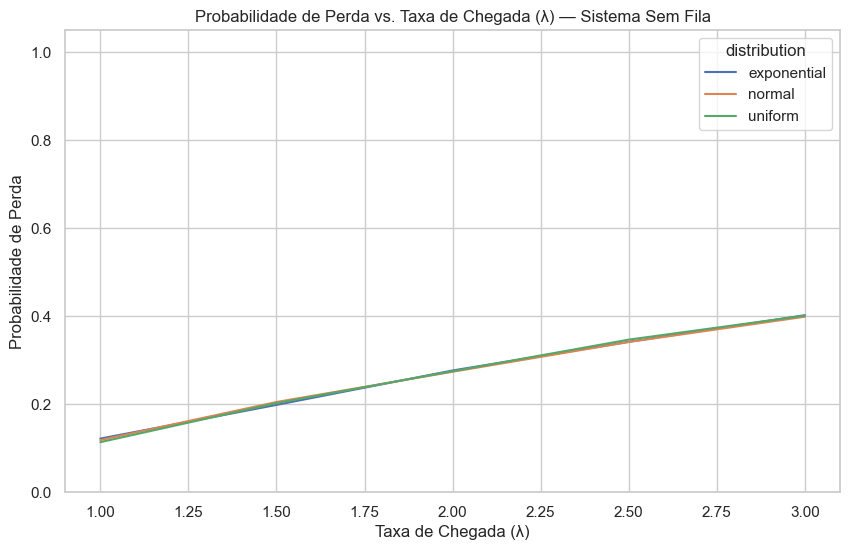

In [114]:
"""
Gráfico: Probabilidade de perda no sistema sem fila (M/G/2/0).
"""

df_loss = df_results[df_results['model'] == 'No Queue']

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_loss,
    x="lambda", y="loss_probability",
    hue="distribution", markers=True, dashes=False
)
plt.title("Probabilidade de Perda vs. Taxa de Chegada (λ) — Sistema Sem Fila")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Probabilidade de Perda")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


In [115]:
def run_multiple_replications(simulation_function, lam, mu, distribution, sim_time, n_replications=30):
    """
    Executa múltiplas replicações de uma simulação e calcula estatísticas resumidas.

    Args:
        simulation_function: Função de simulação a ser chamada.
        lam (float): Taxa de chegada.
        mu (float): Taxa de serviço.
        distribution (str): Distribuição dos tempos de serviço.
        sim_time (float): Tempo total de simulação.
        n_replications (int): Número de replicações a serem executadas.

    Returns:
        pd.DataFrame: Tabela com estatísticas resumidas para cada métrica.
    """
    metrics_list = []

    for _ in range(n_replications):
        result = simulation_function(lam, mu, distribution, sim_time)
        metrics_list.append(result)

    df = pd.DataFrame(metrics_list)

    summary_list = []

    for metric in df.columns:
        mean = df[metric].mean()
        std = df[metric].std(ddof=1)
        stderr = std / np.sqrt(n_replications)
        ci95 = 1.96 * stderr

        summary_list.append({
            'metric': metric,
            'mean': mean,
            'std': std,
            'stderr': stderr,
            'ci95': ci95
        })

    summary_df = pd.DataFrame(summary_list)
    summary_df['lambda'] = lam  # adiciona lambda no DataFrame final

    return summary_df


In [116]:
# Definições necessárias ANTES do loop
n_replications = 30  # Número de replicações
n_servers = 2        # Número de servidores

results_replications = []

# Loop para todos os valores de lambda em arrival_rates
for lam in arrival_rates:
    res = run_multiple_replications(
        simulation_function=simulate_single_queue,
        lam=lam,
        mu=service_rate,
        distribution='exponential',
        sim_time=SIM_TIME,
        n_replications=n_replications
    )
    
    res['model'] = f'Single Queue - {n_servers} servers'
    results_replications.append(res)

# Concatena resultados
df_replications = pd.concat(results_replications, ignore_index=True)

# Exibe amostra dos resultados
df_replications.head()

,metric,mean,std,stderr,ci95,lambda,model
0,avg_waiting_time,0.081201,0.005607,0.001024,0.002006,1.0,Single Queue - 2 servers
1,avg_system_time,0.746057,0.011221,0.002049,0.004015,1.0,Single Queue - 2 servers
2,utilization_server_1,0.331795,0.005066,0.000925,0.001813,1.0,Single Queue - 2 servers
3,utilization_server_2,0.331820,0.005077,0.000927,0.001817,1.0,Single Queue - 2 servers
4,avg_queue_length,0.080316,0.007185,0.001312,0.002571,1.0,Single Queue - 2 servers


In [117]:
# Exemplo para o modelo de duas filas paralelas
result_parallel = run_multiple_replications(
    simulation_function=simulate_two_parallel_queues,
    lam=2.0,
    mu=1.5,
    distribution='exponential',
    sim_time=10000,
    n_replications=30
)

display(result_parallel)

,metric,mean,std,stderr,ci95,lambda
0,avg_waiting_time,0.707034,0.031557,0.005761,0.011293,2.0
1,avg_system_time,1.373722,0.033949,0.006198,0.012149,2.0
2,utilization_server_1,0.665872,0.006392,0.001167,0.002287,2.0
3,utilization_server_2,0.666995,0.006515,0.001189,0.002331,2.0
4,avg_queue_length_1,0.707267,0.038818,0.007087,0.013891,2.0
5,avg_queue_length_2,0.706819,0.037281,0.006806,0.013341,2.0


In [118]:
summary = df_results.groupby(['model', 'distribution'])['avg_system_time'].mean().unstack()
display(summary)

distribution,exponential,normal,uniform
model,,,
Limited Queue,0.666825,0.667033,0.666714
No Queue,0.665464,0.665255,0.665980
Single Queue,5.272642,3.795818,2.870427
Two Parallel Queues,8.003141,8.187420,7.766653


## Intervalo de Confiança Manual (Alta Qualidade)

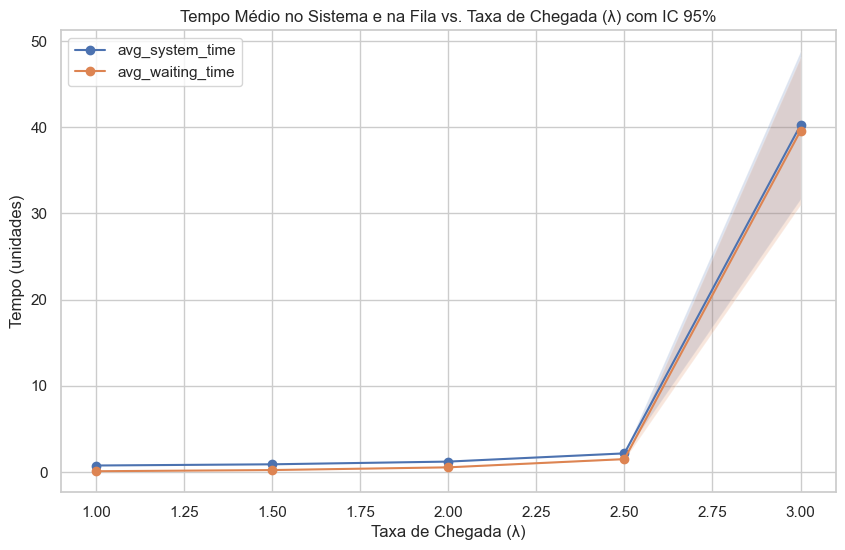

In [119]:
plt.figure(figsize=(10, 6))

for metric in ['avg_system_time', 'avg_waiting_time']:
    data = df_replications[df_replications['metric'] == metric].sort_values('lambda')
    
    plt.plot(
        data['lambda'], data['mean'],
        marker='o', label=f'{metric}'
    )
    
    plt.fill_between(
        data['lambda'],
        data['mean'] - data['ci95'],
        data['mean'] + data['ci95'],
        alpha=0.2
    )

plt.title("Tempo Médio no Sistema e na Fila vs. Taxa de Chegada (λ) com IC 95%")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Tempo (unidades)")
plt.grid(True)
plt.legend()
plt.show()


## Utilização dos Servidores com IC 95%

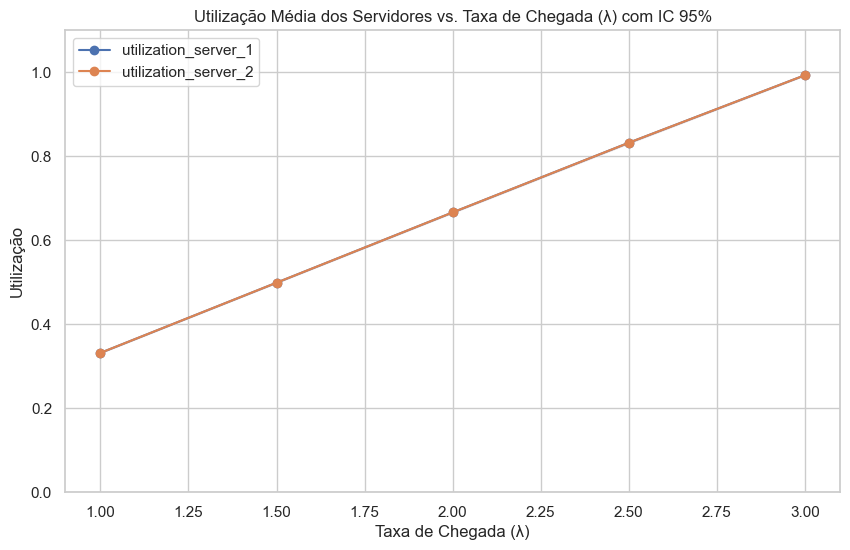

In [120]:
plt.figure(figsize=(10, 6))

for metric in ['utilization_server_1', 'utilization_server_2']:
    data = df_replications[df_replications['metric'] == metric].sort_values('lambda')
    
    plt.plot(
        data['lambda'], data['mean'],
        marker='o', label=f'{metric}'
    )
    
    plt.fill_between(
        data['lambda'],
        data['mean'] - data['ci95'],
        data['mean'] + data['ci95'],
        alpha=0.2
    )

plt.title("Utilização Média dos Servidores vs. Taxa de Chegada (λ) com IC 95%")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Utilização")
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

## Tempo médio no sistema para diferentes lambdas

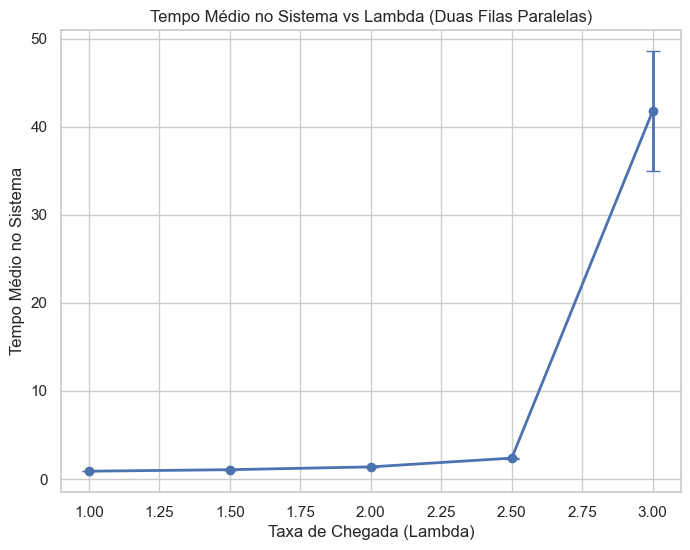

In [121]:
# Exemplo para variar lambda
lambdas = [1, 1.5, 2, 2.5, 3]
means = []
errors = []

for lam in lambdas:
    summary = run_multiple_replications(
        simulation_function=simulate_two_parallel_queues,
        lam=lam,
        mu=1.5,
        distribution='exponential',
        sim_time=10000,
        n_replications=30
    )

    # Filtra a linha da métrica desejada
    avg_system_row = summary[summary['metric'] == 'avg_system_time']

    means.append(avg_system_row['mean'].values[0])
    errors.append(avg_system_row['ci95'].values[0])

# Plot com barra de erro
plt.figure(figsize=(8, 6))
plt.errorbar(lambdas, means, yerr=errors, fmt='-o', capsize=5, linewidth=2)
plt.title('Tempo Médio no Sistema vs Lambda (Duas Filas Paralelas)')
plt.xlabel('Taxa de Chegada (Lambda)')
plt.ylabel('Tempo Médio no Sistema')
plt.grid(True)
plt.show()

## Discussão dos Resultados

- À medida que a taxa de chegada (λ) se aproxima ou ultrapassa a taxa de serviço agregada dos servidores (2 * μ), o sistema começa a saturar.
- O modelo de **fila única** (M/G/2) apresentou desempenho ligeiramente superior em termos de tempo médio no sistema e na fila, especialmente em altas cargas, devido ao melhor balanceamento entre os servidores.
- O modelo de **duas filas paralelas** teve um aumento perceptível no tempo de espera quando as filas estavam desbalanceadas, o que é esperado.
- O modelo **sem fila** apresentou uma **alta probabilidade de perda** à medida que λ aumenta, confirmando a limitação deste tipo de sistema em ambientes de alta demanda.
- As diferenças entre distribuições (exponencial, normal e uniforme) foram notáveis:
    - A distribuição **normal truncada** e **uniforme** resultaram em menores variabilidades de tempo na fila em comparação com a exponencial.
    - A **exponencial** tem maiores flutuações devido à sua natureza de memória nula.

## [EXTRA] Função Geral para Modelos com N Servidores (Fila Única)

In [122]:
"""
Função para simular fila única com N servidores (M/G/N).
"""

def simulate_single_queue_n_servers(
    lam: float, mu: float, distribution: str,
    sim_time: int, n_servers: int
) -> dict:
    """
    Simula um sistema de fila única com N servidores.

    Args:
        lam (float): Taxa de chegada (λ).
        mu (float): Taxa de serviço (μ).
        distribution (str): Distribuição do tempo de serviço ('exponential', 'normal', 'uniform').
        sim_time (int): Tempo total de simulação.
        n_servers (int): Número de servidores.

    Returns:
        dict: Métricas da simulação.
    """

    env = simpy.Environment()
    server = simpy.Resource(env, capacity=n_servers)

    waiting_times = []
    system_times = []
    queue_lengths = []
    busy_times = [0] * n_servers  # Lista para o tempo ocupado de cada servidor

    def customer(name: str, env: simpy.Environment):
        nonlocal busy_times

        arrival_time = env.now

        with server.request() as request:
            queue_entry_time = env.now
            yield request
            queue_exit_time = env.now

            waiting_time = queue_exit_time - queue_entry_time
            service_time = generate_service_time(distribution, mu)

            # Atribui ao servidor menos ocupado
            idx = np.argmin(busy_times)
            busy_times[idx] += service_time

            yield env.timeout(service_time)

            departure_time = env.now

            waiting_times.append(waiting_time)
            system_times.append(departure_time - arrival_time)

    def arrival_process(env: simpy.Environment):
        customer_count = 0
        while True:
            interarrival = generate_interarrival_time(lam)
            yield env.timeout(interarrival)
            customer_count += 1
            env.process(customer(f'Cliente {customer_count}', env))
            queue_lengths.append(len(server.queue))

    env.process(arrival_process(env))
    env.run(until=sim_time)

    avg_waiting_time = np.mean(waiting_times) if waiting_times else 0
    avg_system_time = np.mean(system_times) if system_times else 0
    avg_queue_length = np.mean(queue_lengths) if queue_lengths else 0
    utilization = [bt / sim_time for bt in busy_times]
    avg_utilization = np.mean(utilization)

    return {
        'avg_waiting_time': avg_waiting_time,
        'avg_system_time': avg_system_time,
        'avg_queue_length': avg_queue_length,
        'avg_utilization': avg_utilization,
        'n_servers': n_servers
    }


In [123]:
"""
Execução da simulação para diferentes números de servidores (2, 3 e 4).
"""

# Parâmetros
lambda_range = np.arange(1, 6.5, 0.5)
n_servers_list = [2, 3, 4]

# Lista para armazenar resultados
results_n_servers = []

for n_servers in n_servers_list:
    for lam in lambda_range:
        res = simulate_single_queue_n_servers(
            lam=lam, mu=service_rate,
            distribution='exponential',
            sim_time=SIM_TIME,
            n_servers=n_servers
        )
        res.update({
            'lambda': lam,
            'distribution': 'exponential',
            'model': f'Single Queue - {n_servers} servers'
        })
        results_n_servers.append(res)

# Cria DataFrame
df_n_servers = pd.DataFrame(results_n_servers)


## Gráfico: Tempo Médio no Sistema para N Servidores

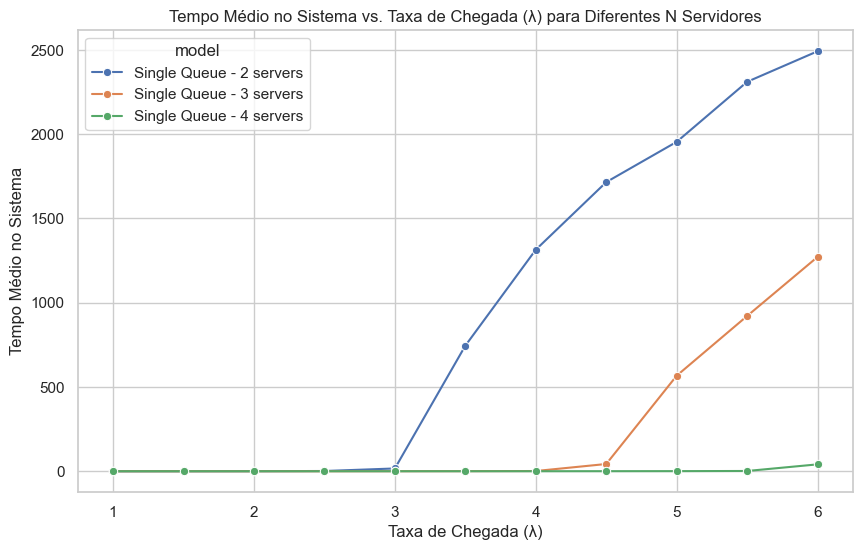

In [124]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_n_servers,
    x="lambda", y="avg_system_time",
    hue="model", marker="o"
)
plt.title("Tempo Médio no Sistema vs. Taxa de Chegada (λ) para Diferentes N Servidores")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Tempo Médio no Sistema")
plt.grid(True)
plt.show()

## Gráfico: Utilização Média dos Servidores para N Servidores

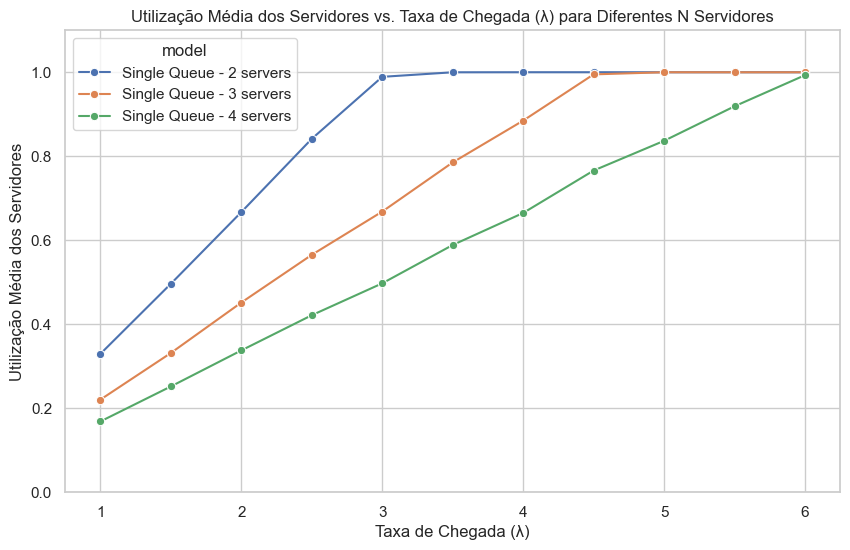

In [125]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_n_servers,
    x="lambda", y="avg_utilization",
    hue="model", marker="o"
)
plt.title("Utilização Média dos Servidores vs. Taxa de Chegada (λ) para Diferentes N Servidores")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Utilização Média dos Servidores")
plt.ylim(0, 1.1)
plt.grid(True)
plt.show()


## Heatmap: Tempo Médio no Sistema

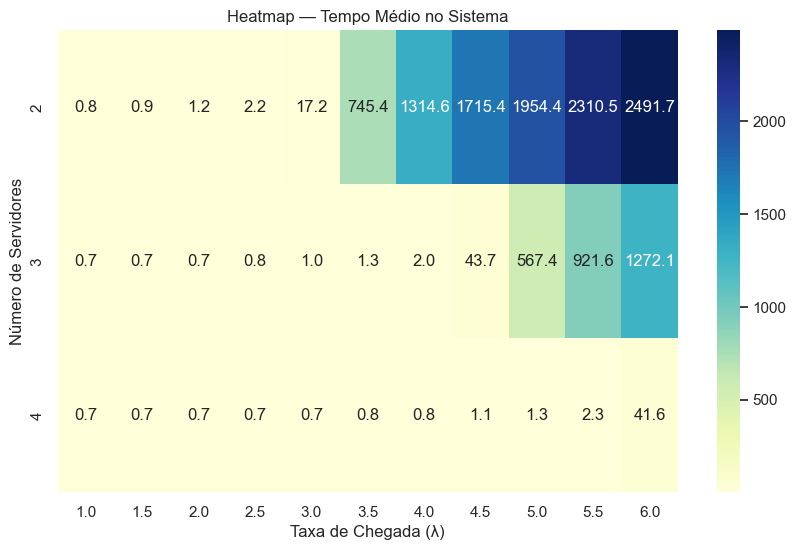

In [126]:
# Prepara dados para o heatmap
heatmap_data = df_n_servers.pivot_table(
    index="n_servers",
    columns="lambda",
    values="avg_system_time"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu"
)
plt.title("Heatmap — Tempo Médio no Sistema")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Número de Servidores")
plt.show()


## Heatmap: Utilização Média dos Servidores

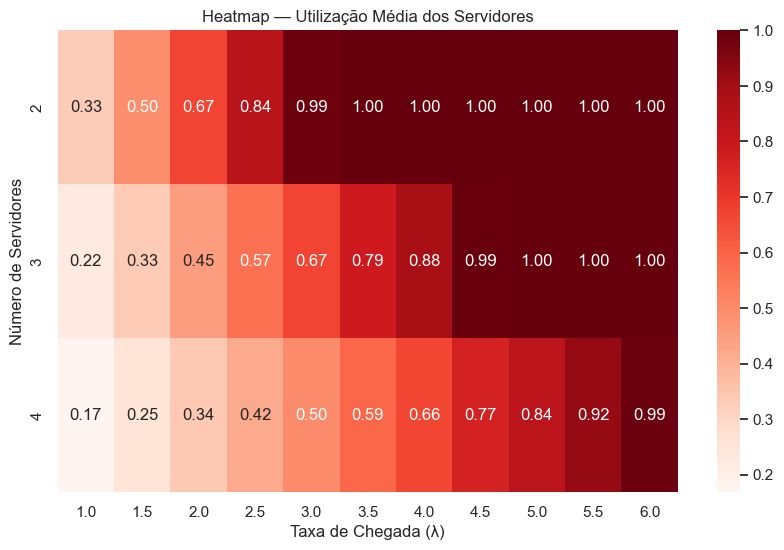

In [127]:
# Prepara dados para o heatmap
heatmap_util = df_n_servers.pivot_table(
    index="n_servers",
    columns="lambda",
    values="avg_utilization"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_util, annot=True, fmt=".2f", cmap="Reds"
)
plt.title("Heatmap — Utilização Média dos Servidores")
plt.xlabel("Taxa de Chegada (λ)")
plt.ylabel("Número de Servidores")
plt.show()


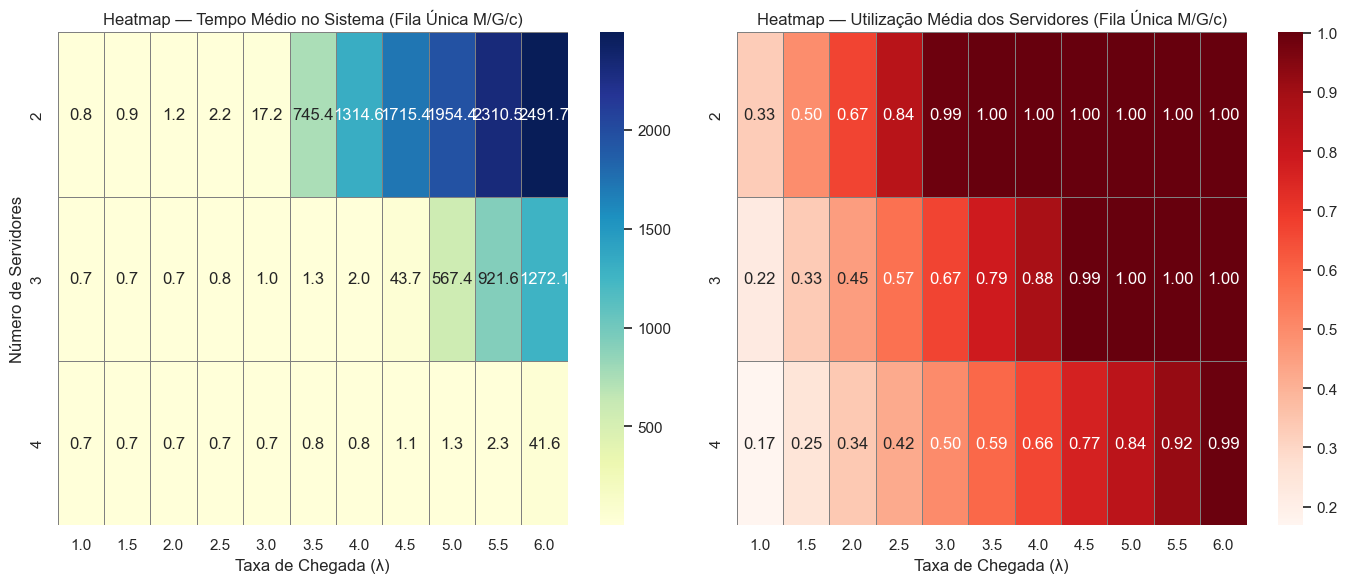

In [128]:
fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Heatmap — Tempo Médio no Sistema
ax0 = plt.subplot(gs[0])
sns.heatmap(
    heatmap_data, annot=True, fmt=".1f",
    cmap="YlGnBu", linewidths=.5, linecolor='gray', ax=ax0
)
ax0.set_title("Heatmap — Tempo Médio no Sistema (Fila Única M/G/c)", fontsize=12)
ax0.set_xlabel("Taxa de Chegada (λ)")
ax0.set_ylabel("Número de Servidores")

# Heatmap — Utilização Média dos Servidores
ax1 = plt.subplot(gs[1])
sns.heatmap(
    heatmap_util, annot=True, fmt=".2f",
    cmap="Reds", linewidths=.5, linecolor='gray', ax=ax1
)
ax1.set_title("Heatmap — Utilização Média dos Servidores (Fila Única M/G/c)", fontsize=12)
ax1.set_xlabel("Taxa de Chegada (λ)")
ax1.set_ylabel("")

plt.tight_layout()
plt.show()


## Discussão - Estudo Adicional

- O aumento no número de servidores resulta em uma redução significativa no tempo médio no sistema, especialmente para taxas de chegada altas.
- Observa-se que, mesmo com 4 servidores, taxas de chegada muito altas (λ ≥ 5.5) ainda levam o sistema a operar próximo da saturação.
- O heatmap de utilização mostra claramente que:
    - Sistemas com poucos servidores atingem rapidamente 100% de utilização.
    - Com o aumento de servidores, a capacidade de absorver maior demanda melhora, mas existe limite — aumento infinito de servidores não é linearmente eficiente.
- A partir dos resultados, é possível balancear entre **custo operacional (número de servidores)** e **nível de serviço (tempo de espera e saturação)**.





## Conclusão

- O modelo de **Fila Única (M/G/2)** oferece melhor balanceamento, especialmente sob alta carga.
- O modelo de **Duas Filas Paralelas** funciona bem sob cargas moderadas, mas apresenta maiores tempos de espera em situações de empate frequente.
- O modelo **Sem Fila (M/G/2/0)** só é viável em situações com baixa demanda, pois rapidamente apresenta altas taxas de perda.

Os resultados permitem avaliar a melhor configuração de filas para diferentes cenários operacionais, balanceando custo (número de servidores) e nível de serviço.
